In [15]:
import numpy as np
import pandas as pd

dane = pd.read_csv("wyciagniete_dane.txt", sep=';')
dane.columns = dane.columns.str.replace(';', '').str.strip()

# constants definitions
au_unit = 1.496e13  # 1 astronomical unit in cm
r_min = 1.0 * au_unit
r_max = 90.0 * au_unit
nr_steps = 100000
r = np.linspace(r_min, r_max, nr_steps) # Tworzy wektor odległości
dr = (r_max - r_min) / nr_steps # Długość pojedynczego kroku (dL)

def protons_density(r):
    # distribution of density as 1/r^2 
    r1 = 1.0 * au_unit
    n1 = 5.0 
    return n1 * (r1 / r)**2

n_p = protons_density(r)
p_density_integral = np.sum(n_p * dr) # Całka z gęstości protonów po odległości

arbitrary_units_to_cm2 = 2.8002852056e-17

dane['Total_Probability'] = dane['Tot_sigma'] * arbitrary_units_to_cm2 * p_density_integral

# 6. Zapisujemy zaktualizowaną tabelę do NOWEGO pliku CSV
dane.to_csv("probability_data.txt", sep=';', index=False)
print("done")

done


Used cross-section for probability calculation: 6.397e-15 cm^2


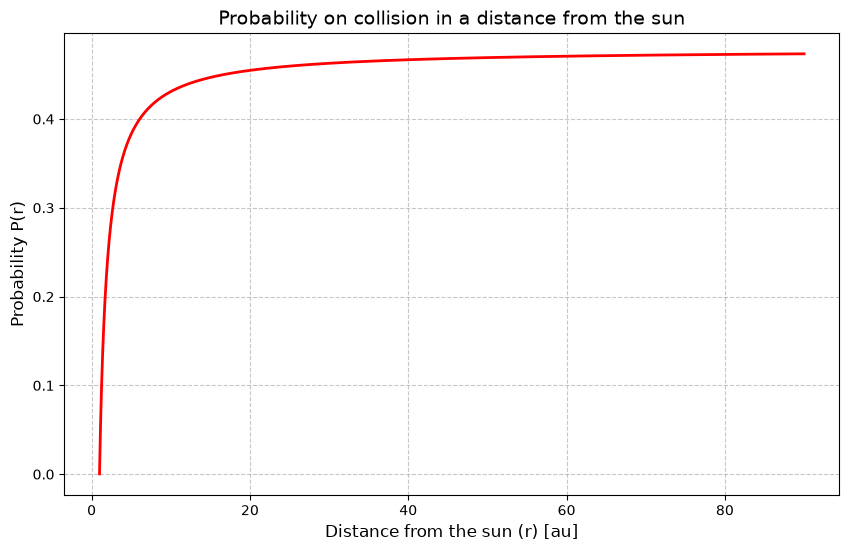

In [23]:
import matplotlib.pyplot as plt

# take arbitrary cross-section in row x ->  .iloc[x] 
sigma_example = dane['Tot_sigma'].iloc[0] * arbitrary_units_to_cm2
print(f"Used cross-section for probability calculation: {sigma_example:.3e} cm^2")
# cumsum -> cumulative sum, gives an array of cumulative values instead of a single number
prawdopodobienstwo1_od_r = np.cumsum(n_p * sigma_example * dr)


plt.figure(figsize=(10, 6))

plt.plot(r / au_unit, prawdopodobienstwo1_od_r, color='red', linewidth=2)
plt.title('Probability on collision in a distance from the sun', fontsize=14)
plt.xlabel('Distance from the sun (r) [au]', fontsize=12)
plt.ylabel('Probability P(r)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

Used cross-section for probability calculation: 4.016e-14 cm^2


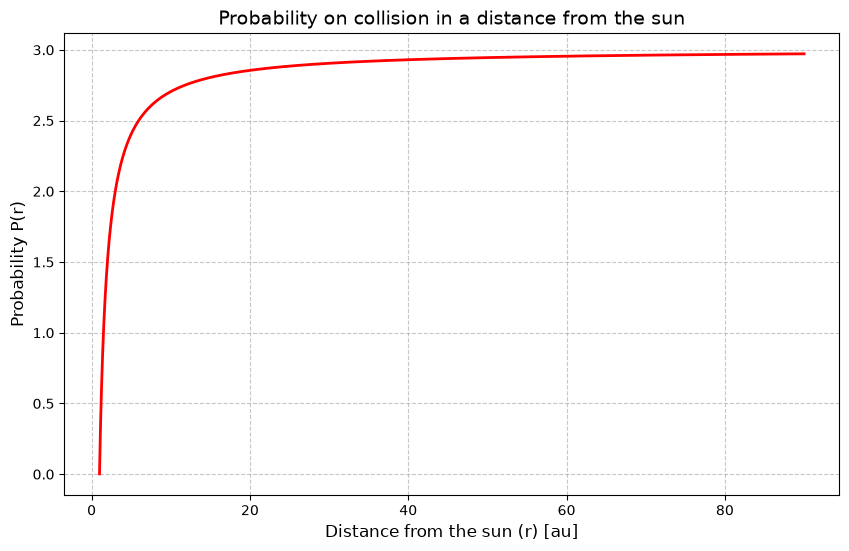

In [ ]:
import matplotlib.pyplot as plt

# take arbitrary cross-section in row x ->  .iloc[x] 
sigma_example = dane['Tot_sigma'].iloc[330] * arbitrary_units_to_cm2
print(f"Used cross-section for probability calculation: {sigma_example:.3e} cm^2")
# cumsum -> cumulative sum, gives an array of cumulative values instead of a single number
prawdopodobienstwo_od_r = np.cumsum(n_p * sigma_example * dr)

plt.figure(figsize=(10, 6))

plt.plot(r / au_unit, prawdopodobienstwo_od_r, color='red', linewidth=2)

plt.title('Probability on collision in a distance from the sun', fontsize=14)
plt.xlabel('Distance from the sun (r) [au]', fontsize=12)
plt.ylabel('Probability P(r)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

Used cross-section for probability calculation: 2.534e-13 cm^2


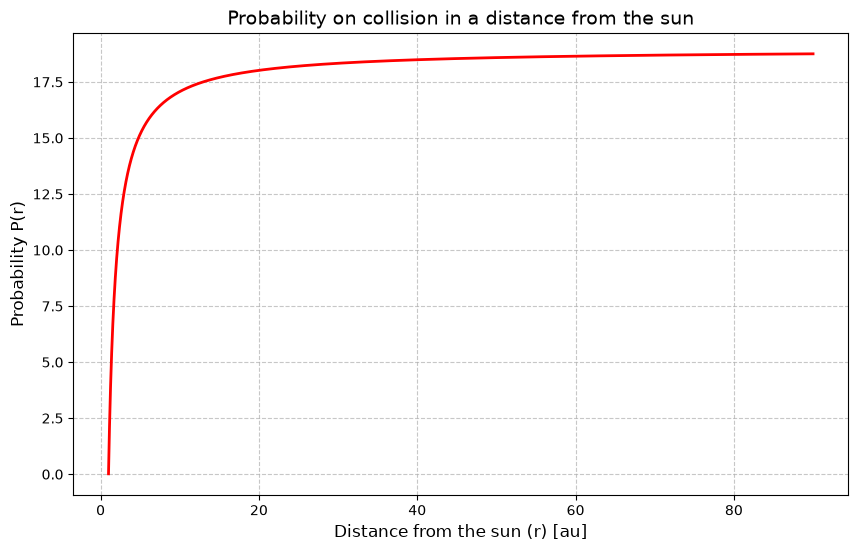

In [ ]:
import matplotlib.pyplot as plt

# take arbitrary cross-section in row x ->  .iloc[x] 
sigma_example = dane['Tot_sigma'].iloc[660] * arbitrary_units_to_cm2
print(f"Used cross-section for probability calculation: {sigma_example:.3e} cm^2")
# cumsum -> cumulative sum, gives an array of cumulative values instead of a single number
prawdopodobienstwo_od_r = np.cumsum(n_p * sigma_example * dr)

plt.figure(figsize=(10, 6))

plt.plot(r / au_unit, prawdopodobienstwo_od_r, color='red', linewidth=2)

plt.title('Probability on collision in a distance from the sun', fontsize=14)
plt.xlabel('Distance from the sun (r) [au]', fontsize=12)
plt.ylabel('Probability P(r)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.show()

Used cross-section for probability1 calculation (blue): 6.397e-15 cm^2
Used cross-section for probability2 calculation (red): 4.016e-14 cm^2
Used cross-section for probability3 calculation (green): 2.534e-13 cm^2


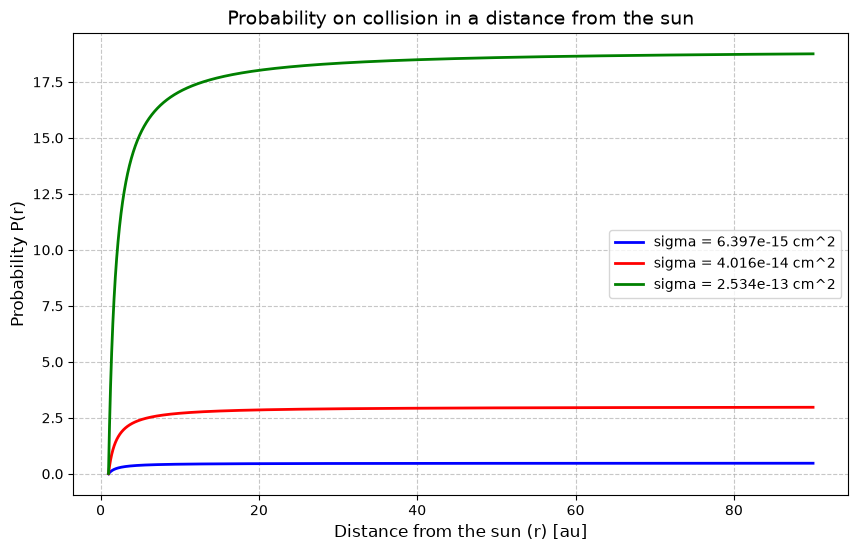

In [26]:
import matplotlib.pyplot as plt

# take arbitrary cross-section in row x ->  .iloc[x] 
sigma_example1 = dane['Tot_sigma'].iloc[0] * arbitrary_units_to_cm2
print(f"Used cross-section for probability1 calculation (blue): {sigma_example1:.3e} cm^2")
# cumsum -> cumulative sum, gives an array of cumulative values instead of a single number
prawdopodobienstwo1_od_r = np.cumsum(n_p * sigma_example1 * dr)

sigma_example2 = dane['Tot_sigma'].iloc[330] * arbitrary_units_to_cm2
print(f"Used cross-section for probability2 calculation (red): {sigma_example2:.3e} cm^2")
prawdopodobienstwo2_od_r = np.cumsum(n_p * sigma_example2 * dr)

sigma_example3 = dane['Tot_sigma'].iloc[660] * arbitrary_units_to_cm2
print(f"Used cross-section for probability3 calculation (green): {sigma_example3:.3e} cm^2")
prawdopodobienstwo3_od_r = np.cumsum(n_p * sigma_example3 * dr)

plt.figure(figsize=(10, 6))

plt.plot(r / au_unit, prawdopodobienstwo1_od_r, color='blue', linewidth=2, label = f'sigma = {sigma_example1:.3e} cm^2')
plt.plot(r / au_unit, prawdopodobienstwo2_od_r, color='red', linewidth=2, label = f'sigma = {sigma_example2:.3e} cm^2')
plt.plot(r / au_unit, prawdopodobienstwo3_od_r, color='green', linewidth=2, label = f'sigma = {sigma_example3:.3e} cm^2')
plt.title('Probability on collision in a distance from the sun', fontsize=14)
plt.xlabel('Distance from the sun (r) [au]', fontsize=12)
plt.ylabel('Probability P(r)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.show()

In [33]:
import pandas as pd
import numpy as np

# upload data
dane = pd.read_csv("wyciagniete_dane.txt", sep=';')
dane.columns = dane.columns.str.replace(';', '').str.strip()

#constants
solar_wind_vel = [300, 500, 1000] # km/s
mu_eV = 7.4962491838e8 # reduced mass in eV/c^2
c = 299792.458 # speed of light in km/s

for v in solar_wind_vel:
    # dokladna energia in CM dla danego v_sw
    energia_obliczona = 0.5 * mu_eV * (v / c)**2
    
    # wartość bezwzględna różnicy energii dokladnej i wszystkich w pliku
    roznice = np.abs(dane['CM_energy'] - energia_obliczona)
    
    # znajduje indeks wiersza, w którym różnica jest najmniejsza
    najblizszy_indeks = roznice.idxmin()

    # import numbers from OBTAINED index 
    znaleziona_energia = dane['CM_energy'].iloc[najblizszy_indeks]
    znaleziona_sigma = dane['Tot_sigma'].iloc[najblizszy_indeks]
    
    # Wyświetlanie wyniku
    
    print(f"\nPrędkość wiatru: {v} km/s")
    print(f" -> Obliczona energia CM: {energia_obliczona:.2f} eV")
    print(f" -> Najbliższa w pliku: {znaleziona_energia:.2f} eV")
    print(f" -> Przekrój (Tot_sigma): {znaleziona_sigma} a.u.")
    print(f"Najbliższa energia w pliku dla prędkości {v} km/s znajduje się w wierszu: {najblizszy_indeks}")


Prędkość wiatru: 300 km/s
 -> Obliczona energia CM: 375.33 eV
 -> Najbliższa w pliku: 398.11 eV
 -> Przekrój (Tot_sigma): 39.917703005 a.u.
Najbliższa energia w pliku dla prędkości 300 km/s znajduje się w wierszu: 46

Prędkość wiatru: 500 km/s
 -> Obliczona energia CM: 1042.59 eV
 -> Najbliższa w pliku: 1000.00 eV
 -> Przekrój (Tot_sigma): 19.730883601 a.u.
Najbliższa energia w pliku dla prędkości 500 km/s znajduje się w wierszu: 50

Prędkość wiatru: 1000 km/s
 -> Obliczona energia CM: 4170.35 eV
 -> Najbliższa w pliku: 3981.07 eV
 -> Przekrój (Tot_sigma): 6.8273337472 a.u.
Najbliższa energia w pliku dla prędkości 1000 km/s znajduje się w wierszu: 56
